# K-means model selection for Beijing PM data

This notebook evaluates K-means on the Beijing PM observations using precipitation, humidity, temperature, dew point, instant wind speed, and pressure.

Instead of fixing $k=3$, it compares several values of $k$ with the elbow method and silhouette score.

In [1]:
# =============================================================================
# STEP 1 — Data Ingestion & Cleaning
# Owner: Danish
# Dataset: PM2.5 Data of Five Chinese Cities (UCI ML Repository)
# Coverage: hourly observations, 2010-01-01 → 2015-12-31
#
# Selective PDF-recommendation version
# ─────────────────────────────────────────────────────────────────────────────
# Incorporated here:
#   1) Do NOT treat missing precipitation as "dry hour" / 0.0.
#      Precipitation is retained for diagnostics but excluded from the main model.
#   2) Avoid unlimited PM target imputation. Only one-hour PM gaps are forward-filled.
#      Remaining missing PM rows are dropped.
#   3) Preserve circular wind direction via wind_sin and wind_cos, when cbwd exists.
#
# Deliberately NOT changed here:
#   • PM station columns are still averaged to city-hour PM for comparability with
#     the original notebook. A station-level refactor is better as a separate
#     robustness/extension notebook because it changes the unit of analysis.
# =============================================================================

import os
import pandas as pd
import numpy as np

# ── 1. File map ───────────────────────────────────────────────────────────────
# Place the five raw CSVs in the same directory as this notebook.
FILE_MAP = {
    "Beijing":   "BeijingPM20100101_20151231.csv",
    "Shanghai":  "ShanghaiPM20100101_20151231.csv",
    "Guangzhou": "GuangzhouPM20100101_20151231.csv",
    "Chengdu":   "ChengduPM20100101_20151231.csv",
    "Shenyang":  "ShenyangPM20100101_20151231.csv",
}

# Structural columns shared across all five datasets.
# cbwd = combined wind direction, used to create wind_sin/wind_cos.
# precipitation is retained only for diagnostics because it is absent / missing in
# some city files and should NOT be imputed to 0.0.
CORE_COLS = ["city", "year", "month", "day", "hour", "season",
             "PM", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "cbwd", "precipitation"]

# Main model features available immediately after Step 1.
# Precipitation is intentionally excluded from the main model. If you later add
# reliable precipitation data for all cities, add it back as a robustness model.
# YEAH, NO WE HAVE TO INCLUDE PRECIPITATION, or do we? Google says no!
WEATHER_FEATURES = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "boundary_layer_height (m)", "cloud_cover (%)"]
WIND_FEATURES = ["wind_sin", "wind_cos", "wind_dir_missing"]
WIND_DIRECTION = ["wind_sin", "wind_cos"]

# ── 2. Heating-regime definition ──────────────────────────────────────────────
# Treatment variable (causal block): binary indicator that equals 1 when
# the city is inside the government-mandated northern heating zone AND the
# calendar month falls within the active heating season (November–March).

HEATING_CITIES  = {"Beijing", "Shenyang"}
HEATING_MONTHS  = {11, 12, 1, 2, 3}          # Nov–Mar (inclusive)

def engineer_heating_regime(df: pd.DataFrame) -> pd.DataFrame:
    """Add binary `heating_regime` column (treatment variable for causal block)."""
    df = df.copy()
    df["heating_regime"] = (
        df["city"].isin(HEATING_CITIES) & df["month"].isin(HEATING_MONTHS)
    ).astype(int)
    return df

# ── 3. Wind-direction encoding ────────────────────────────────────────────────
# Meteorological convention: North = 0°, East = 90°, South = 180°, West = 270°.
# The UCI files often contain cbwd values such as NE, NW, SE, SW and sometimes
# "cv" (calm/variable). Calm/variable has undefined direction, so we encode both
# sin/cos as 0 and set wind_dir_missing = 1.

WIND_ANGLE_MAP = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}
CALM_OR_VARIABLE = {"CV", "CALM", "VARIABLE", "VAR", "NONE", ""}

def add_wind_direction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Encode cbwd as circular wind_sin/wind_cos plus an undefined-direction flag."""
    df = df.copy()

    if "cbwd" not in df.columns:
        df["cbwd"] = np.nan

    cbwd = df["cbwd"].astype("string").str.strip().str.upper()
    angle = cbwd.map(WIND_ANGLE_MAP).astype(float)

    calm_or_variable = cbwd.isin(CALM_OR_VARIABLE)
    unmapped_or_missing = cbwd.isna() | (angle.isna() & ~calm_or_variable)
    undefined_direction = calm_or_variable | unmapped_or_missing

    theta = np.deg2rad(angle)
    df["wind_sin"] = np.sin(theta)
    df["wind_cos"] = np.cos(theta)

    # Undefined direction: no meaningful direction vector; set vector to zero
    # and let wind_dir_missing tell the model that direction was unavailable.
    df.loc[undefined_direction, ["wind_sin", "wind_cos"]] = 0.0
    df["wind_dir_missing"] = undefined_direction.astype(int)
    df["wind_angle"] = angle

    return df

# ── 4. Ingestion loop & Ersetzung für Beijing ──────────────────────────────────

def load_city(city: str, filename: str) -> pd.DataFrame:
    """Read one city CSV and return a cleaned slice with unified columns."""
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Expected '{filename}' in the working directory."
        )

    df = pd.read_csv(filename, na_values=["NA", "NaN", " ", ""])
    df["city"] = city

    pm_cols = [c for c in df.columns if c.upper().startswith("PM_")]
    if not pm_cols:
        raise ValueError(f"No PM_* columns found in {filename}.")
    df["PM"] = df[pm_cols].mean(axis=1)

    for optional_col in ["cbwd", "precipitation"]:
        if optional_col not in df.columns:
            df[optional_col] = np.nan

    available = [c for c in CORE_COLS if c in df.columns]
    df = df[available].copy()
    return df

def replace_city_weather_with_exact_data(
    df_all_cities: pd.DataFrame, city_name: str, new_weather_path: str
) -> pd.DataFrame:
    """Replaces the imprecise UCI weather data for a specific city with the precise Open-Meteo CSV data."""
    print(
        f"\n── Replacing {city_name} weather data with high-resolution data ────────────────"
    )

    # 1. Separate data: Isolate only the specific city
    df_city = df_all_cities[df_all_cities["city"] == city_name].copy()
    df_other_cities = df_all_cities[
        df_all_cities["city"] != city_name
    ].copy()

    # If no data exists for this city, skip it
    if len(df_city) == 0:
        print(
            f"  ⚠️  No data found for {city_name} in the dataset. Skipping."
        )
        return df_all_cities

    # 2. Load new weather file (skip metadata rows)
    df_weather_new = pd.read_csv(new_weather_path, skiprows=3)

    # Parse timestamps correctly (ISO-8601 format with 'T')
    df_weather_new["time"] = pd.to_datetime(
        df_weather_new["time"], format="%Y-%m-%dT%H:%M"
    )

    # 3. Build a synchronization datetime axis for the city frame
    df_city["temp_datetime"] = pd.to_datetime(
        df_city[["year", "month", "day", "hour"]]
    )

    # 4. Drop old weather columns AND already existing new additional columns
    # This prevents suffix conflicts (_x, _y) in subsequent loop iterations!
    old_weather_columns = [
        "TEMP",
        "PRES",
        "HUMI",
        "DEWP",
        "cbwd",
        "Iws",
        "precipitation",
    ]

    # Which columns are brought in by the new weather file? (after mapping)
    new_features_mapped = [
        "wind_direction_10m (°)",
        "boundary_layer_height (m)",
        "rain (mm)",
        "snowfall (cm)",
        "TEMP",
        "PRES",
        "HUMI",
        "DEWP",
        "Iws",
        "precipitation",
        "wind_gusts_10m (km/h)",
        "cloud_cover (%)",
    ]

    # Delete all old weather columns AND all columns that are about to enter via the merge
    columns_to_drop = set(
        old_weather_columns
        + new_features_mapped
        + ["wind_sin", "wind_cos", "wind_dir_missing"]
    )

    df_city = df_city.drop(
        columns=[col for col in columns_to_drop if col in df_city.columns]
    )

    # 5. Merge based on the exact timestamp
    df_city_new = pd.merge(
        df_city,
        df_weather_new,
        left_on="temp_datetime",
        right_on="time",
        how="inner",
    ).drop(
        columns=["temp_datetime", "time"]
    )  # 'time' is no longer required

    # 6. Map new column names to your project's naming scheme
    column_mapping = {
        "temperature_2m (°C)": "TEMP",
        "pressure_msl (hPa)": "PRES",
        "relative_humidity_2m (%)": "HUMI",
        "dew_point_2m (°C)": "DEWP",
        "wind_speed_10m (km/h)": "Iws",
        "precipitation (mm)": "precipitation",
    }
    df_city_new = df_city_new.rename(columns=column_mapping)

    # 7. Utilize the continuous wind direction (0-360°) for true smooth sin/cos tracking
    theta = np.deg2rad(df_city_new["wind_direction_10m (°)"])
    df_city_new["wind_sin"] = np.sin(theta)
    df_city_new["wind_cos"] = np.cos(theta)

    # Since we now have complete data, set missing flags to 0
    df_city_new["wind_dir_missing"] = 0

    # 8. Fill additional features in other cities with NaN
    additional_features = [
        c for c in df_city_new.columns if c not in df_other_cities.columns
    ]
    for col in additional_features:
        df_other_cities[col] = np.nan

    # 9. Re-unite both slices into a single dataframe
    df_other_cities = df_other_cities[
        df_city_new.columns
    ]  # Synchronize column order
    df_final_pipeline = pd.concat(
        [df_city_new, df_other_cities], ignore_index=True
    )
    print(f"  ✅ Successfully ingested. {city_name} rows: {len(df_city_new):,}")

    return df_final_pipeline


# === ACTUAL PIPELINE EXECUTION ===

print(
    "── Ingesting city datasets ──────────────────────────────────────────────"
)
city_frames = []
for city, filename in FILE_MAP.items():
    frame = load_city(city, filename)
    print(f"  {city:10s}  {len(frame):>7,} raw rows  |  PM cols averaged")
    city_frames.append(frame)

# 1. Concatenate all raw datasets
df_raw = pd.concat(city_frames, ignore_index=True)

# 2. Add heating regime flags
df_raw = engineer_heating_regime(df_raw)

# 3. Calculate wind features for remaining 4 cities (if necessary)
df_raw = add_wind_direction_features(df_raw)

# 4. NOW: Replace weather data for EACH city sequentially
openmeteo_files = {
    "Beijing": "open-meteo-Beijing.csv",
    "Chengdu": "open-meteo-Chengdu.csv",
    "Guangzhou": "open-meteo-Guangzhou.csv",
    "Shanghai": "open-meteo-Shanghai.csv",
    "Shenyang": "open-meteo-Shenyang.csv",
}

# Replace weather records city by city
for city, filepath in openmeteo_files.items():
    df_raw = replace_city_weather_with_exact_data(df_raw, city, filepath)

print(
    f"\n  Combined & Replaced (raw):  {len(df_raw):>7,} rows × {df_raw.shape[1]} columns"
)

# ── 5. Temporal ordering ──────────────────────────────────────────────────────
# Sort the full panel chronologically within each city so that forward-fill
# operates strictly along the time axis.

df_raw = (df_raw
          .sort_values(["city", "year", "month", "day", "hour"])
          .reset_index(drop=True))

# =============================================================================
# Sensor anomaly handling: convert hidden -9999.0 error codes to NaN.
# =============================================================================
print("── Processing data quality check: Purging -9999 sensor faults ──────────")
for col in ["HUMI", "DEWP"]:
    if col in df_raw.columns:
        fault_count = (df_raw[col] == -9999.0).sum()
        print(f"  Found {fault_count:,} sensor error records (-9999.0) in column: {col}")
        df_raw[col] = df_raw[col].replace(-9999.0, np.nan)
print("  Purge successful. Anomalies converted to NaN placeholders.\n")

# Capture true raw missingness before PM forward-fill and row dropping.
missing_diagnostic_cols = ["PM"] + WEATHER_FEATURES + ["wind_direction_10m (°)", "precipitation"]
raw_missing_before_handling = (
    df_raw.groupby("city", observed=True)[missing_diagnostic_cols]
    .apply(lambda g: g.isna().sum())
)
precip_nulls_by_city = df_raw.groupby("city", observed=True)["precipitation"].apply(lambda g: g.isna().sum())

# ── 6. Missing-value handling ─────────────────────────────────────────────────
# Selective PDF-response strategy:
#   (a) PM target: allow only one-hour forward fill within each city. This avoids
#       turning long monitor outages into artificial flat PM periods.
#   (b) Weather features: drop rows with missing core weather values.
#   (c) Precipitation: do not impute as zero. Keep for diagnostics, but exclude
#       it from the main model.

print("── Missing-value strategy ───────────────────────────────────────────────")
print("  PM target       : forward-fill within city with limit=1 hour only")
print("  Weather features: drop rows with missing TEMP/PRES/HUMI/DEWP/Iws")
print("  Precipitation   : keep missing as NaN; excluded from main model")

pm_nulls_before = df_raw["PM"].isna().sum()
df_raw["PM"] = df_raw.groupby("city", observed=True)["PM"].ffill(limit=1)
pm_nulls_after = df_raw["PM"].isna().sum()
print(f"  PM missing before limited ffill : {pm_nulls_before:,}")
print(f"  PM missing after limited ffill  : {pm_nulls_after:,}")

# Wind direction is added before dropna so all downstream steps can use it.
#THIS IS OUTDATED AND HAS ALREADY HAPPENED
#df_raw = add_wind_direction_features(df_raw)

#wind_undefined_by_city = df_raw.groupby("city", observed=True)["wind_dir_missing"].sum()
#print("\n── Wind-direction encoding ──────────────────────────────────────────────")
#print("  Created wind_sin, wind_cos, and wind_dir_missing from cbwd")
#print("  Undefined/calm/variable/missing wind-direction rows by city:")
#print(wind_undefined_by_city.to_string())

# Drop rows where model-critical fields remain missing. Precipitation is not in
# this subset because it is not used in the main model.
n_before_drop = len(df_raw)
CRITICAL_MODEL_COLS = ["PM"] + WEATHER_FEATURES + WIND_FEATURES

df_clean = df_raw.dropna(subset=CRITICAL_MODEL_COLS).reset_index(drop=True)
n_dropped = n_before_drop - len(df_clean)
print(f"\n  Rows dropped (PM/weather/wind critical nulls): {n_dropped:,}")
print(f"  Rows retained (clean panel)                 : {len(df_clean):,}")

# ── 7. Treatment variable engineering ────────────────────────────────────────
df_clean = engineer_heating_regime(df_clean)

regime_counts = df_clean.groupby("city", observed=True)["heating_regime"].sum()
print(f"\n── heating_regime summary (treated hours per city) ─────────────────────")
print(regime_counts.to_string())

# ── 8. Data-type enforcement ──────────────────────────────────────────────────
# Categorical city saves memory and speeds groupby operations downstream.
df_clean["city"]    = df_clean["city"].astype("category")
df_clean["season"]  = df_clean["season"].astype("category")

# Ensure temporal integers are native int (not float from merge artefacts)
for col in ["year", "month", "day", "hour"]:
    df_clean[col] = df_clean[col].astype(int)

# ── 9. Sanity checks ──────────────────────────────────────────────────────────
print("\n── Sanity checks ────────────────────────────────────────────────────────")

# (i) Year coverage
print(f"  Year range  : {df_clean['year'].min()} – {df_clean['year'].max()}")

# (ii) No remaining nulls in model-critical columns
null_summary = df_clean[CRITICAL_MODEL_COLS + ["heating_regime"]].isnull().sum()
assert null_summary.sum() == 0, f"Unexpected nulls remaining:\n{null_summary[null_summary > 0]}"
print("  Null check  : PASSED — no missing values in critical model columns")

# (iii) Precipitation may still contain NaNs by design
precip_missing_clean = df_clean["precipitation"].isna().sum()
print(f"  Precip NaNs : {precip_missing_clean:,} retained by design; not used in main model")

# (iv) heating_regime is strictly binary
assert set(df_clean["heating_regime"].unique()).issubset({0, 1}), "heating_regime contains non-binary values"
print("  Binary check: PASSED — heating_regime ∈ {0, 1}")

# (v) All five cities present
assert set(df_clean["city"].cat.categories) == set(FILE_MAP.keys()), "Missing cities in clean panel"
print(f"  Cities      : {sorted(df_clean['city'].cat.categories.tolist())}")

# (vi) PM values are non-negative (physical constraint)
assert (df_clean["PM"] >= 0).all(), "Negative PM2.5 values detected — check source data"
print(f"  PM range    : {df_clean['PM'].min():.1f} – {df_clean['PM'].max():.1f} µg/m³")

# ── 10. Final overview ────────────────────────────────────────────────────────
print("\n── Final dataset ────────────────────────────────────────────────────────")
print(f"  Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Memory : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

display(df_clean.head())
print("\n── Column dtypes & null counts ──────────────────────────────────────────")
df_clean.info()

print("\n── Descriptive statistics ───────────────────────────────────────────────")
display(df_clean.describe())

# =============================================================================
# STEP 1b — Pre-cleaning diagnostics (raw missingness, coverage, range checks)
# =============================================================================

print("── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────")
display(raw_missing_before_handling)
print(f"\n  Total raw rows                 : {len(df_raw):,}")
print(f"  Total rows dropped (Step 1)    : {n_dropped:,} "
      f"({n_dropped / len(df_raw):.2%})")

# ── Precipitation coverage by city ───────────────────────────────────────────
print("\n── Precipitation coverage by city ──────────────────────────────────────")
print("  Missing counts are retained as true missingness; no zero imputation applied.")
print(precip_nulls_by_city.to_string())

# ── Range / sanity checks on weather features (sensor-fault detection) ──────
print("\n── Weather feature range checks (post-clean) ───────────────────────────")
range_checks = df_clean[WEATHER_FEATURES + WIND_FEATURES].agg(["min", "max", "mean", "std"]).round(2)
display(range_checks)

# Flag physically implausible values
implausible = {
    "TEMP": ((df_clean["TEMP"] < -40) | (df_clean["TEMP"] > 50)).sum(),
    "PRES": ((df_clean["PRES"] < 850) | (df_clean["PRES"] > 1100)).sum(),
    "HUMI": ((df_clean["HUMI"] < 0) | (df_clean["HUMI"] > 100)).sum(),
    "Iws":  (df_clean["Iws"] < 0).sum(),
}
print("\n  Implausible-value counts (flagged, not removed):")
for k, v in implausible.items():
    print(f"    {k:6s}: {v}")

# ── Season consistency check ─────────────────────────────────────────────────
print("\n── Season label consistency ─────────────────────────────────────────────")
season_month_map = df_clean.groupby("season", observed=True)["month"].unique()
display(season_month_map.to_frame())

# ── 11. Export clean panel ───────────────────────────────────────────────────
# `df_clean` is the master panel carried forward into all subsequent blocks.
# Steps 2 (EDA), 3 (Causal), 4 (Supervised), and 5 (Unsupervised) all import it.
print("\n✓ Step 1 complete. Use `df_clean` in all downstream steps.")
print("  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,")
print("  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.")

── Ingesting city datasets ──────────────────────────────────────────────
  Beijing      52,584 raw rows  |  PM cols averaged
  Shanghai     52,584 raw rows  |  PM cols averaged
  Guangzhou    52,584 raw rows  |  PM cols averaged
  Chengdu      52,584 raw rows  |  PM cols averaged
  Shenyang     52,584 raw rows  |  PM cols averaged

── Replacing Beijing weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Beijing rows: 52,584

── Replacing Chengdu weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Chengdu rows: 52,584

── Replacing Guangzhou weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Guangzhou rows: 52,584

── Replacing Shanghai weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Shanghai rows: 52,584

── Replacing Shenyang weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Shenyang rows: 52,584

  Combined & Replaced (raw)

,city,year,month,day,hour,season,PM,heating_regime,wind_angle,TEMP,...,HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
0,Beijing,2010,1,1,23,4.0,129.0,1,NaN,-4.1,...,42.0,5.0,339.0,30.0,1019.3,11.2,87.0,-3.583679e-01,9.335804e-01,0
1,Beijing,2010,1,2,0,4.0,148.0,1,135.0,-4.4,...,45.0,4.9,343.0,30.0,1019.5,10.8,90.0,-2.923717e-01,9.563048e-01,0
2,Beijing,2010,1,2,1,4.0,159.0,1,135.0,-4.5,...,48.0,5.0,360.0,30.0,1020.7,9.7,86.0,-2.449294e-16,1.000000e+00,0
3,Beijing,2010,1,2,2,4.0,181.0,1,135.0,-4.6,...,55.0,4.5,29.0,45.0,1021.0,7.2,97.0,4.848096e-01,8.746197e-01,0
4,Beijing,2010,1,2,3,4.0,138.0,1,135.0,-4.9,...,66.0,4.3,90.0,95.0,1022.0,7.9,98.0,1.000000e+00,6.123234e-17,0



── Column dtypes & null counts ──────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 175993 entries, 0 to 175992
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   city                       175993 non-null  category
 1   year                       175993 non-null  int64   
 2   month                      175993 non-null  int64   
 3   day                        175993 non-null  int64   
 4   hour                       175993 non-null  int64   
 5   season                     175992 non-null  category
 6   PM                         175993 non-null  float64 
 7   heating_regime             175993 non-null  int64   
 8   wind_angle                 146402 non-null  float64 
 9   TEMP                       175993 non-null  float64 
 10  DEWP                       175993 non-null  float64 
 11  precipitation              175993 non-null  float64 
 12  rain (mm

,year,month,day,hour,PM,heating_regime,wind_angle,TEMP,DEWP,precipitation,...,HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
count,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,146402.000000,175993.000000,175993.000000,175993.000000,...,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.0
mean,2013.346054,6.665600,15.785043,11.504441,73.616802,0.181786,179.353288,15.631964,8.518941,0.118049,...,66.656731,9.556671,176.825550,500.263420,1015.058017,20.365794,55.835181,0.052370,0.096513,0.0
std,1.379877,3.443725,8.807908,6.923134,68.791684,0.385669,105.673602,11.153460,13.169707,0.554068,...,22.410720,5.748036,112.616555,549.476034,9.510479,10.688150,41.266143,0.628578,0.769960,0.0
min,2010.000000,1.000000,1.000000,0.000000,1.000000,0.000000,45.000000,-29.200000,-34.200000,0.000000,...,5.000000,0.000000,1.000000,10.000000,984.100000,1.400000,0.000000,-1.000000,-1.000000,0.0
25%,2012.000000,4.000000,8.000000,6.000000,29.000000,0.000000,45.000000,7.900000,0.300000,0.000000,...,51.000000,5.400000,76.000000,85.000000,1007.300000,12.200000,7.000000,-0.515038,-0.766044,0.0
50%,2013.000000,7.000000,16.000000,12.000000,53.000000,0.000000,135.000000,18.000000,11.200000,0.000000,...,71.000000,8.200000,170.000000,320.000000,1014.800000,18.000000,66.000000,0.104528,0.309017,0.0
75%,2014.000000,10.000000,23.000000,18.000000,93.500000,0.000000,315.000000,24.500000,19.200000,0.000000,...,86.000000,12.500000,291.000000,735.000000,1022.200000,26.300000,99.000000,0.601815,0.857167,0.0
max,2015.000000,12.000000,31.000000,23.000000,1134.666667,1.000000,315.000000,41.200000,28.200000,22.200000,...,100.000000,58.400000,360.000000,4990.000000,1046.600000,108.700000,100.000000,1.000000,1.000000,0.0


── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────


...


  Total raw rows                 : 262,920
  Total rows dropped (Step 1)    : 86,927 (33.06%)

── Precipitation coverage by city ──────────────────────────────────────
  Missing counts are retained as true missingness; no zero imputation applied.
city
Beijing      0
Chengdu      0
Guangzhou    0
Shanghai     0
Shenyang     0

── Weather feature range checks (post-clean) ───────────────────────────


,TEMP,PRES,HUMI,DEWP,Iws,boundary_layer_height (m),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
min,-29.20,984.10,5.00,-34.20,0.00,10.00,0.00,-1.00,-1.00,0.0
max,41.20,1046.60,100.00,28.20,58.40,4990.00,100.00,1.00,1.00,0.0
mean,15.63,1015.06,66.66,8.52,9.56,500.26,55.84,0.05,0.10,0.0
std,11.15,9.51,22.41,13.17,5.75,549.48,41.27,0.63,0.77,0.0



  Implausible-value counts (flagged, not removed):
    TEMP  : 0
    PRES  : 0
    HUMI  : 0
    Iws   : 0

── Season label consistency ─────────────────────────────────────────────


,month
season,
1.0,"[3, 4, 5]"
2.0,"[6, 7, 8]"
3.0,"[9, 10, 11]"
4.0,"[1, 2, 12]"



✓ Step 1 complete. Use `df_clean` in all downstream steps.
  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,
  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.


Calculation of the correlation between our weather features. Depending on the results, we select the measures to chose next.
When calculating the different weather regimes, we need to include the weather data of all cities at the same time. Else, every city would have a certain number of weather regimes, but the set of regimes from city "A" would be different from city "B". Hence, we would not be able to compute the effect of the weather regimes.

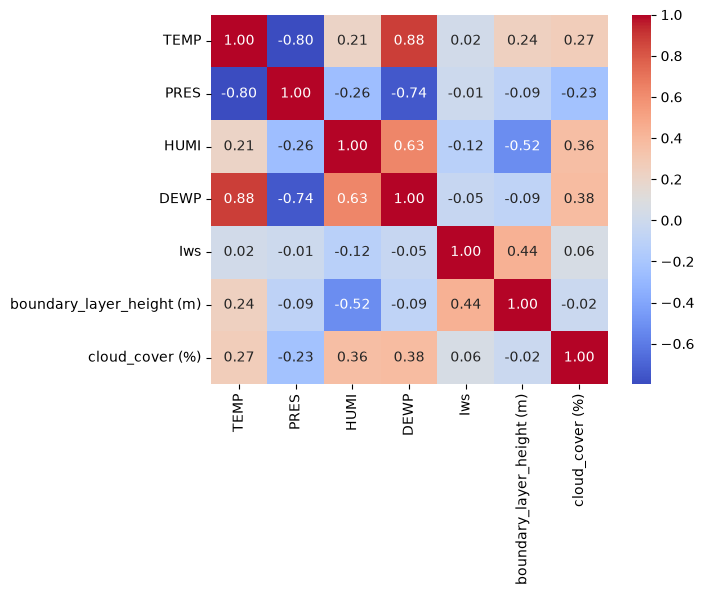

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
#We are calculating our k-means (different weather regimes) over all cities, else we would not be able to compare the weather regimes
#Calculate correlation
#ALL_FEATURES = WEATHER_FEATURES + WIND_DIRECTION #We just want the weather for now 
corr_matrix = df_clean[WEATHER_FEATURES].corr()

# Show correlation as heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

We can see from the plot, that some features are highly correlated, e.g. the dew point and the air temperature, the air pressure at sea level and the temperature but also boundary layer height and humidity. For the upcoming calculations it is necessary to use uncorrelated features(?), therefore we will use Principal Component Analysis to get uncorrelated features.
Before we can use pca, we must scale our data. This is due to certain limitations of the algorithms, as they just use the numerical values to "understand" the importance. A feature with a value of 20 will be 10 times as important to the algorithm as a feature with a value of 2, but due to the units used there are differences between the values. FOr example, pressure, measuread in milli bar is about 1000, while temperature, measured in degree centigrade, will be roughly between -50 and + 50. THe algorithm would consider pressure to be more important than temperature. Standardisation solves this issue by transforming all data into a certain range. There are four different scalers available, we will use the StandardScaler. REASON MISSING!
After scaling has completed, we could start with the pc-analysis. Before conducting the analysis, we must decide how many components we want. There is a tradeoff. If we specify a number too low, we do not explain not ennough of the models variance, if we choose a number too high, we overfit. There is a rule of thumb (CITATION MISSING) we should use the smallest number "n" which explains more than 80% of the variance. We therefore run a script to identify this number.

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Standardize data (Necessary for PCA & K-Means!)
scaler = StandardScaler()
wetter_scaled = scaler.fit_transform(df_clean[WEATHER_FEATURES].dropna())

# Step 3: Fit full PCA (7 components for all 7 variables)
# This is necessary to calculate the maximum total variance
pca_full = PCA(n_components=len(WEATHER_FEATURES))
pca_full.fit(wetter_scaled)

# Step 4: Display results clearly
print("── EXPLAINED VARIANCE PER PRINCIPAL COMPONENT (PCA) ──────────────────────────")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"Principal Component {i+1} (PC{i+1}) explains: {var*100:.1f}% of the variance")

print("\n── CUMULATIVE INFORMATION COVERAGE ────────────────────")
cum_var_2 = np.sum(pca_full.explained_variance_ratio_[:2]) * 100
cum_var_3 = np.sum(pca_full.explained_variance_ratio_[:3]) * 100
cum_var_4 = np.sum(pca_full.explained_variance_ratio_[:4]) * 100

print(f"➡ With n=2 components (PC1 + PC2), you cover {cum_var_2:.1f}% of the weather information.")
print(f"➡ With n=3 components (PC1 + PC2 + PC3), you cover {cum_var_3:.1f}% of the weather information.")
print(f"➡ With n=4 components (PC1 + PC2 + PC3 + PC4), you cover {cum_var_4:.1f}% of the weather information.")

── EXPLAINED VARIANCE PER PRINCIPAL COMPONENT (PCA) ──────────────────────────
Principal Component 1 (PC1) explains: 43.3% of the variance
Principal Component 2 (PC2) explains: 25.1% of the variance
Principal Component 3 (PC3) explains: 14.3% of the variance
Principal Component 4 (PC4) explains: 9.7% of the variance
Principal Component 5 (PC5) explains: 4.6% of the variance
Principal Component 6 (PC6) explains: 2.9% of the variance
Principal Component 7 (PC7) explains: 0.1% of the variance

── CUMULATIVE INFORMATION COVERAGE ────────────────────
➡ With n=2 components (PC1 + PC2), you cover 68.4% of the weather information.
➡ With n=3 components (PC1 + PC2 + PC3), you cover 82.7% of the weather information.
➡ With n=4 components (PC1 + PC2 + PC3 + PC4), you cover 92.4% of the weather information.


As we can see, the smallest n explaining more than 80% of the variance is n=3, explaining 82% of the variance. Therefore, we perfom the pca with n=3

In [4]:


# Step 2: Apply PCA (e.g. reduction to the 3 most imporant, uncorrelated components)
pca = PCA(n_components=3)
wetter_pca = pca.fit_transform(wetter_scaled)

Now, we will use two methods to decide an the number "k" for our K-means-Analysis, the silhouette score and the elbow method. Both desribe different aspects of our data.

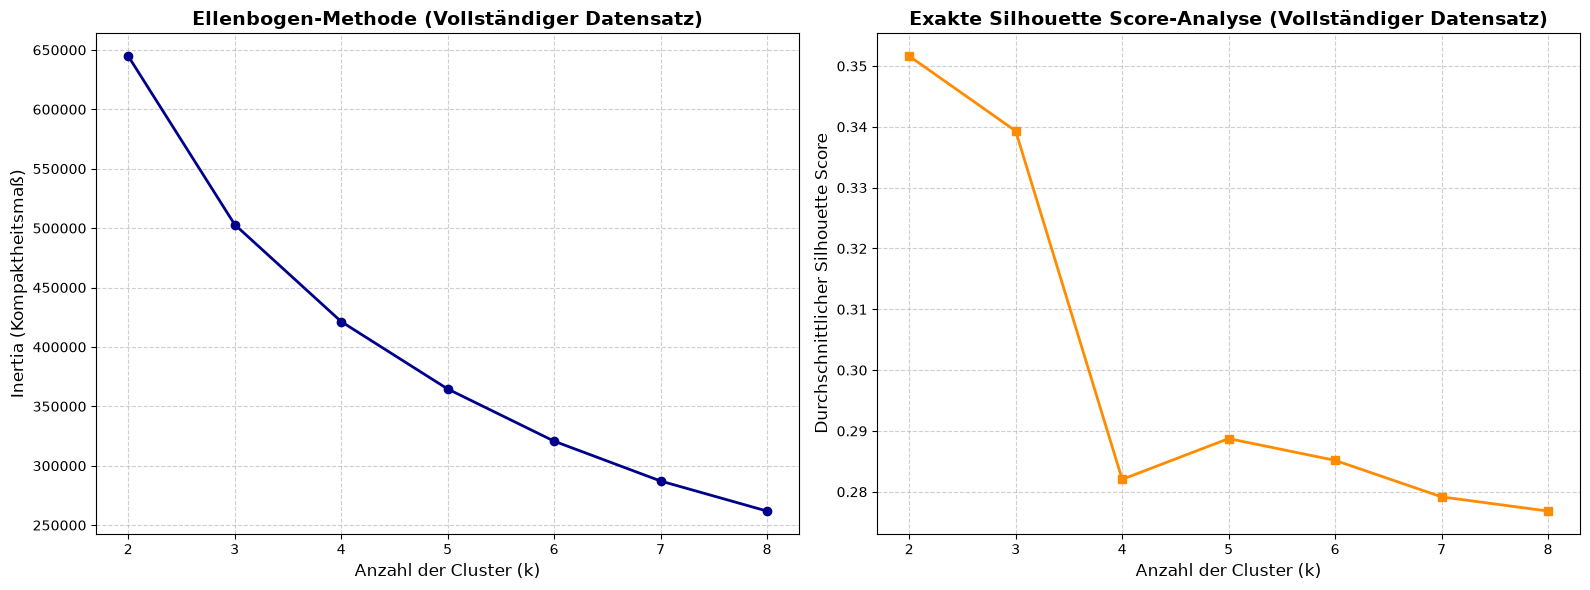

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# 1. Parameter definieren (Gesamter Datensatz)
k_range = range(2, 9)
inertia_values = []
silhouette_scores = []

# 2. Schleife über alle k (Nutzt die vollen 40.000 Zeilen ohne Sampling)
for k in k_range:
    # K-Means Modell initialisieren und fitten
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(wetter_pca)
    
    # Werte für die Diagramme speichern
    inertia_values.append(kmeans.inertia_)
    
    # Berechnet den exakten Score über alle Zeilen (nutzt ca. 12 GB RAM)
    score = silhouette_score(wetter_pca, labels)
    silhouette_scores.append(score)

# 3. Diagramme nebeneinander ausgeben
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Diagramm 1: Ellenbogen-Methode (Inertia)
ax1.plot(k_range, inertia_values, marker='o', color='darkblue', linewidth=2)
ax1.set_title('Ellenbogen-Methode (Vollständiger Datensatz)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Anzahl der Cluster (k)', fontsize=12)
ax1.set_ylabel('Inertia (Kompaktheitsmaß)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(k_range)

# Diagramm 2: Exakter Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', color='darkorange', linewidth=2)
ax2.set_title('Exakte Silhouette Score-Analyse (Vollständiger Datensatz)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Anzahl der Cluster (k)', fontsize=12)
ax2.set_ylabel('Durchschnittlicher Silhouette Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(k_range)

plt.tight_layout()
plt.show()

Based on the diagrams, we are selecting k=4

In [7]:
# Schritt 3: Apply K-Means to the PCA-components

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(wetter_pca)

Additionally, we have a look at the loadings of the Principal components. 

In [8]:
import pandas as pd

# Calculate the weights of the original features per principal component
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=WEATHER_FEATURES
)
print("Unique sine-values:", df_clean['wind_sin'].nunique())
print("Unique cosine-values:", df_clean['wind_cos'].nunique())
print(loadings)

Unique sine-values: 318
Unique cosine-values: 318
                                PC1       PC2       PC3
TEMP                       0.500129  0.265530 -0.251976
PRES                      -0.477803 -0.186120  0.259911
HUMI                       0.351027 -0.445946  0.316934
DEWP                       0.558750 -0.010857 -0.052405
Iws                       -0.028384  0.471572  0.593080
boundary_layer_height (m) -0.044090  0.686010  0.015851
cloud_cover (%)            0.288799 -0.053642  0.643246


Next, we plot our clusters in a 2D view showing PC1 and PC2. We can use the diagram to judge, if the different clusters are well separated.

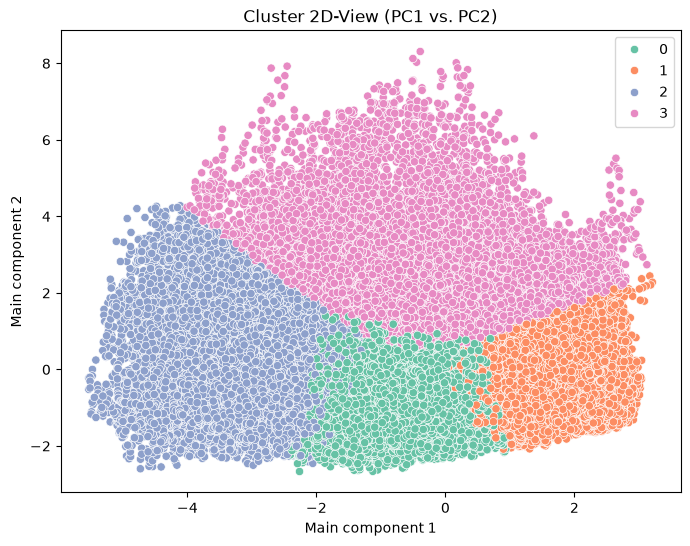

In [9]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=wetter_pca[:, 0], 
    y=wetter_pca[:, 1], 
    hue=clusters, 
    palette='Set2'
)
plt.title('Cluster 2D-View (PC1 vs. PC2)')
plt.xlabel('Main component 1')
plt.ylabel('Main component 2')
plt.show()

We can see, that Cluster0 has a bit fuzzy boardes. All other boardes are fine.

175993
Length plot_df  175993


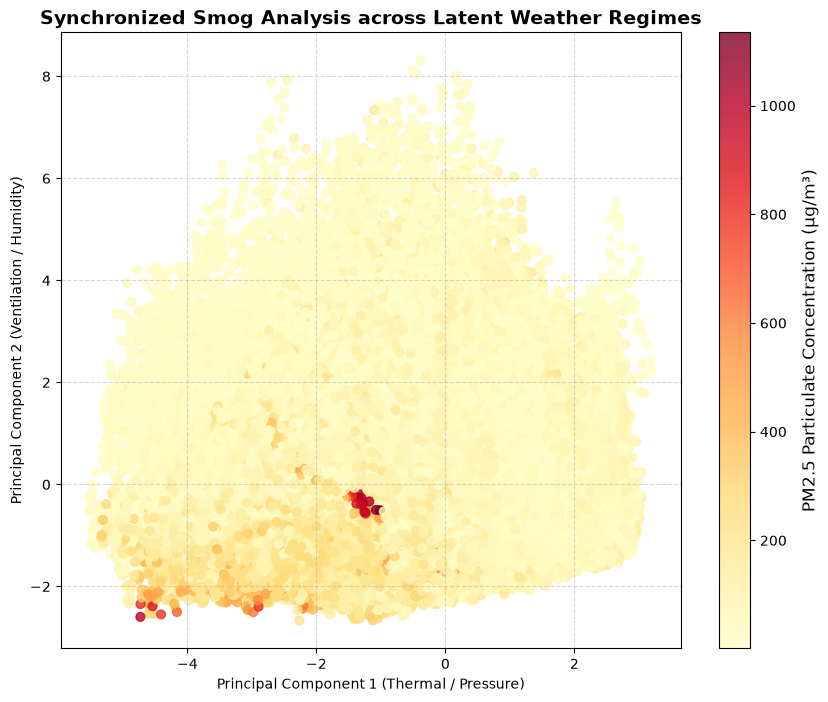

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Retrieve the original indices of the filtered weather data
# (Ensures that the rows from the PCA perfectly align with the rows in df_clean)
weather_data_index = (
    df_clean[["HUMI", "TEMP", "DEWP", "Iws", "PRES", "wind_sin", "wind_cos"]]
    .dropna()
    .index
)

# 2. Create a temporary plot DataFrame that is fully synchronized
# MAJOR ISSUE: PM IS AVERAGED OVER ALL STATIONS OF ONE CITY
plot_df = pd.DataFrame(
    {
        "PC1": wetter_pca[:, 0],
        "PC2": wetter_pca[:, 1],
        "PM25": df_clean.loc[weather_data_index, "PM"],
    }
)
print(len(df_clean))
print("Length plot_df ", len(plot_df))

# 3. Drop rows where the target air quality metric (PM2.5) is missing
plot_df = plot_df.dropna(subset=["PM25"])

# 4. Plotting stage - X, Y, and color tracking arrays are now guaranteed to match in length
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    x=plot_df["PC1"],
    y=plot_df["PC2"],
    c=plot_df["PM25"],  # Color vector matches the exact length of PC1 and PC2
    cmap="YlOrRd",
    s=40,
    alpha=0.8,
)

# Add colorbar axis
cbar = plt.colorbar(scatter)
cbar.set_label("PM2.5 Particulate Concentration (µg/m³)", fontsize=12)

plt.title(
    "Synchronized Smog Analysis across Latent Weather Regimes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Principal Component 1 (Thermal / Pressure)")
plt.ylabel("Principal Component 2 (Ventilation / Humidity)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [11]:
# CORRECTION: Assign the IDs directly to the main DataFrame (both have exactly 51,765 rows)
df_clean["Cluster"] = clusters
print("Length df_clean ", len(df_clean))

# Define the columns for which we want to calculate the profile
# (Use your current, new features here!)
current_weather_columns = [
    "TEMP",
    "PRES",
    "HUMI",
    "DEWP",
    "Iws",
    "precipitation",
    "PM",
]

# Only NOW we filter out the columns and remove potential NaNs (e.g., in PM)
analysis_df = df_clean[current_weather_columns + ["Cluster"]].dropna().copy()
print("Length analysis_df ", len(analysis_df))

# 3. Calculate the mean for each weather variable per cluster
cluster_profile = analysis_df.groupby("Cluster").mean()
print("Length cluster_profile ", len(cluster_profile))

# Display the table in the notebook
print(
    "── ACTUAL PROFILE MEANS PER CLUSTER ──────────────────────────────────"
)
print(cluster_profile.round(2))

Length df_clean  175993
Length analysis_df  175993
Length cluster_profile  4
── ACTUAL PROFILE MEANS PER CLUSTER ──────────────────────────────────
          TEMP     PRES   HUMI   DEWP    Iws  precipitation     PM
Cluster                                                           
0        10.08  1020.44  74.47   5.40   8.87           0.06  95.33
1        23.97  1007.49  80.53  20.15   8.13           0.24  60.00
2        -0.44  1026.55  43.47 -12.45   9.05           0.00  85.04
3        22.81  1011.24  44.75   8.83  14.70           0.04  55.50


In the next segment, we try to "fingerprint" all our identified sectors and see how much time each city spends within those weather regimes

── ABSOLUTE HOURS PER CITY AND CLUSTER (SORTED) ──────────────────
Cluster        0      1      2     3
city                                
Beijing    11249  12865  17095  9632
Shenyang    5792   5614   8662  6017
Shanghai   13219  13298   2747  5659
Chengdu    12387  14190   1127  2934
Guangzhou   7272  21410    745  4079

── PERCENTAGE DISTRIBUTION PER CITY (ROW TOTAL = 100%) ──────────────
Cluster       0     1     2     3
city                             
Beijing    22.1  25.3  33.6  18.9
Shenyang   22.2  21.5  33.2  23.1
Shanghai   37.9  38.1   7.9  16.2
Chengdu    40.4  46.3   3.7   9.6
Guangzhou  21.7  63.9   2.2  12.2


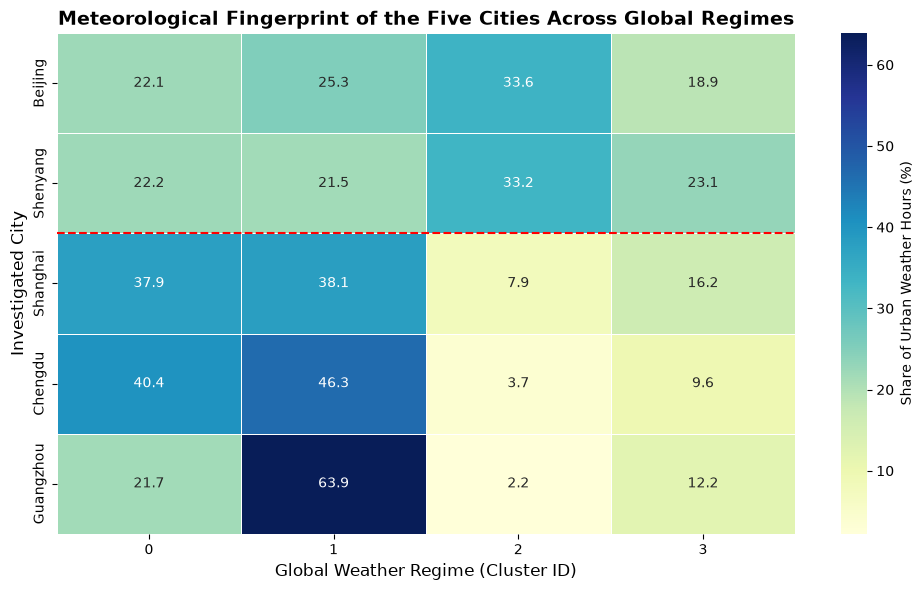

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate absolute frequencies (hours per city and cluster)
crosstab_abs = pd.crosstab(df_clean["city"], df_clean["Cluster"])

# 2. Convert to percentages per city (row sum = 100%)
crosstab_pct = (
    pd.crosstab(df_clean["city"], df_clean["Cluster"], normalize="index") * 100
)

# ── NEW: Define explicit order (Northern cities first, then Southern cities) ──
desired_order = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]
crosstab_pct = crosstab_pct.reindex(desired_order)
crosstab_abs = crosstab_abs.reindex(desired_order)

print(
    "── ABSOLUTE HOURS PER CITY AND CLUSTER (SORTED) ──────────────────"
)
print(crosstab_abs)
print(
    "\n── PERCENTAGE DISTRIBUTION PER CITY (ROW TOTAL = 100%) ──────────────"
)
print(crosstab_pct.round(1))

# 3. Draw scientific heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    crosstab_pct,
    annot=True,  # Display numbers inside the cells
    fmt=".1f",  # One decimal place
    cmap="YlGnBu",  # Scientific color palette
    cbar_kws={"label": "Share of Urban Weather Hours (%)"},
    linewidths=0.5,
)

# Visual separator in the plot: a horizontal line between Northern and Southern cities
# Since Beijing and Shenyang are the first two rows (index 0 and 1), we draw the line at y=2
plt.axhline(
    y=2,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="North/South Boundary (Heating Zone)",
)

plt.title(
    "Meteorological Fingerprint of the Five Cities Across Global Regimes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Global Weather Regime (Cluster ID)", fontsize=12)
plt.ylabel("Investigated City", fontsize=12)
plt.tight_layout()
plt.show()

The northern cities spend a more-or less equal amount of time in all four clusters. In contrast, the southern cities spend 80% of their time in cluster 0 and 2.
We can see, that Cluster 2 is much more likely to be populated by the northern cities than the southern.

Following up, we will calculate a heatmap of all four clusters.

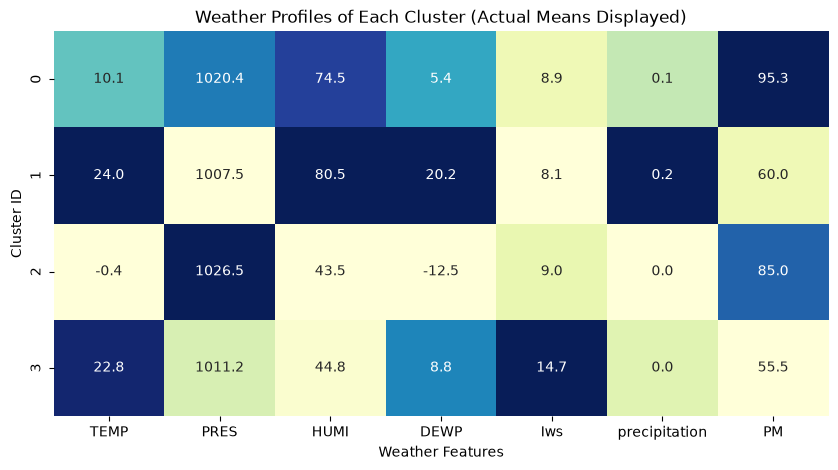

In [14]:
from sklearn.preprocessing import MinMaxScaler
# Normalize the mean values to a scale from 0 to 1,
# allowing a fair comparison of temperature and air pressure in the same heatmap.
plot_scaler = MinMaxScaler()
cluster_profile_scaled = pd.DataFrame(
    plot_scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index,
)

# Draw heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    cluster_profile_scaled,
    annot=cluster_profile,
    fmt=".1f",
    cmap="YlGnBu",
    cbar=False,
)
plt.title("Weather Profiles of Each Cluster (Actual Means Displayed)")
plt.ylabel("Cluster ID")
plt.xlabel("Weather Features")
plt.show()

Cluster 2 is warm with an average temperature of 24°C. At the same time is very humid with a RH of 80% and a Dewpoint of 20°C. 
Clusters 2 and 3 are nearly exclusive to the northern cities.
Cluster 2 is really cold having and average temperature of -0,4°C. Additionally, the relative humidity is really low but it has a rather high air pressure.
Cluster 3 has an average temperature comparable to CLuster 1 but its noticeably less humid with an RH of 45% and a dew point of 9°C. Also, it is windy.
WHY IS PM PART OF THE DIAGRAM?

The same data as above is presented as a box plot.

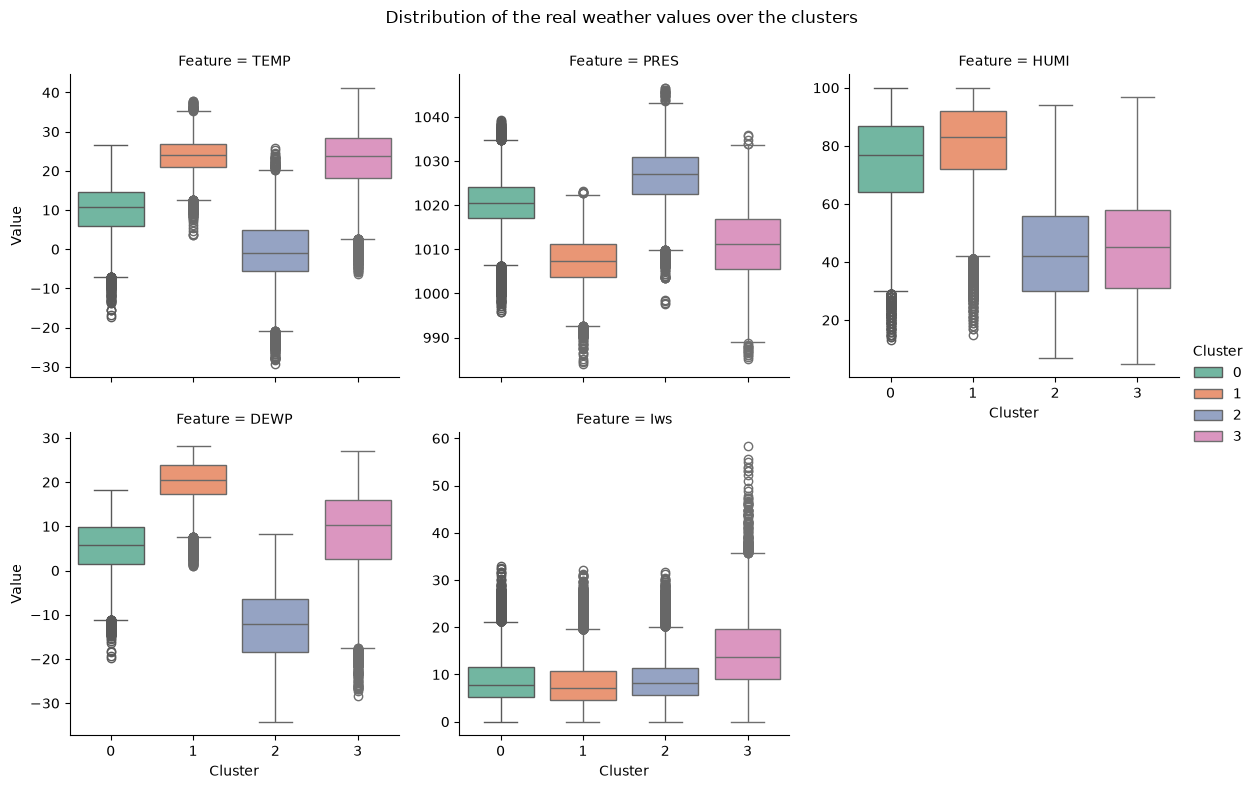

In [16]:
import seaborn as sns
features_to_plot = ["TEMP", "PRES", "HUMI", "DEWP", "Iws"]
# Melts the DataFrame for Seaborn FacetGrid
df_melt = df_clean.melt(id_vars=['Cluster'], value_vars=features_to_plot, 
                        var_name='Feature', value_name='Value')

g = sns.FacetGrid(df_melt, col="Feature", hue="Cluster", col_wrap=3, sharey=False, height=4, palette='Set2')
g.map(sns.boxplot, "Cluster", "Value", order=[0,1,2,3])
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of the real weather values over the clusters')
plt.show()

In [17]:
# 1. Filter the columns for the smog analysis (pure original values)
# Replace 'PM' with your exact column name (e.g., 'PM_Dongsi' or 'PM')
pm_feature = "PM"

# 2. Calculate the most critical economic metrics per cluster
pm_analysis = (
    df_clean.groupby("Cluster")[pm_feature]
    .agg(
        hourly_observations="count",
        average_pm25="mean",
        median_pm25="median",
        maximum_pm25="max",
    )
    .round(2)
)

print("── PM2.5 POLLUTION BURDEN PER ATMOSPHERIC REGIME ──────────────────────────")
print(pm_analysis)

── PM2.5 POLLUTION BURDEN PER ATMOSPHERIC REGIME ──────────────────────────
         hourly_observations  average_pm25  median_pm25  maximum_pm25
Cluster                                                              
0                      49919         95.33        72.00       1134.67
1                      67377         60.00        47.00        512.00
2                      30376         85.04        58.67       1065.50
3                      28321         55.50        41.25        761.00


C:\Users\olive\AppData\Local\Temp\ipykernel_2840\1468801100.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


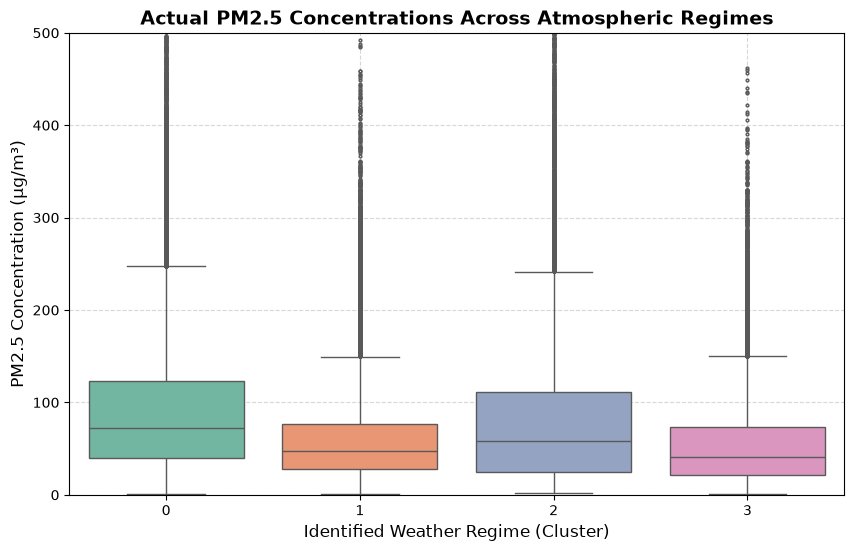

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Box plot of the unscaled PM2.5 values per cluster
sns.boxplot(
    data=df_clean,
    x="Cluster",
    y=pm_feature,
    palette="Set2",
    fliersize=2,  # Makes the outlier points smaller and more legible
)

# Economically sensible limitation of the Y-axis (e.g., up to 500 μg/m³) to keep the box readable
plt.ylim(0, 500)

plt.title(
    "Actual PM2.5 Concentrations Across Atmospheric Regimes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Identified Weather Regime (Cluster)", fontsize=12)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [19]:
import scipy.stats as stats
import pandas as pd
from scikit_posthocs import posthoc_dunn

# STRATEGY: Execute the target separation diagnostics independently for periods 
# when urban heating is completely deactivated (Pure Baseline) versus when it is active.
# This prevents policy timeline shocks from contaminating our meteorological cluster validation.

regime_scenarios = [
    (0, "Heating OFF (Pure Atmospheric Weather Baseline)"), 
    (1, "Heating ON (Mandatory Policy Active)")
]

for regime_status, regime_name in regime_scenarios:
    print("\n" + "="*80)
    print(f" SUB-SAMPLE VALIDATION RUN: {regime_name}")
    print("="*80)
    
    # 1. Filter the synchronized dataframe for the specific policy status
    df_sub = df_clean[df_clean['heating_regime'] == regime_status]
    
    if len(df_sub) == 0:
        print("⚠️ No concurrent observations found for this regime segment. Skipping.")
        continue
        
    # 2. Omnibus Assessment: Global Kruskal-Wallis Test across the 4 weather clusters
    # (Replace 'PM' with your exact target variable column string if modified)
    cluster_groups = [df_sub[df_sub['Cluster'] == i]['PM'].dropna() for i in range(4)]
    kw_stat, kw_p = stats.kruskal(*cluster_groups)
    
    print(f"Global Kruskal-Wallis H-statistic: {kw_stat:.2f}")
    print(f"Global asymptotic p-value:         {kw_p:.4e}")
    if kw_p < 0.01:
        print("➡ Inference: Statistically distinct PM2.5 environments exist within this subset.")
    
    # 3. Descriptive Stratification: Construct the Target Separation Matrix
    target_table = df_sub.groupby('Cluster')['PM'].agg(
        hourly_observations='count',
        mean_pm25='mean',
        median_pm25='median',
        std_deviation='std',
        maximum_pm25='max'
    ).round(1)
    
    print("\n── PM2.5 Target Distribution Matrix:")
    print(target_table)
    
    # 4. Pairwise Deep-Dive: Post-Hoc Dunn's Test with Bonferroni Family-Wise Error Correction
    if kw_p < 0.05:
        print("\n── Pairwise Dunn's Disparity Matrix (Bonferroni-Adjusted p-values):")
        dunn_matrix = posthoc_dunn(df_sub, val_col='PM', group_col='Cluster', p_adjust='bonferroni')
        print(dunn_matrix.round(4))
        print("\n➡ Note: Cells under 0.05 prove significant ambient variance between specific cluster nodes.")


 SUB-SAMPLE VALIDATION RUN: Heating OFF (Pure Atmospheric Weather Baseline)
Global Kruskal-Wallis H-statistic: 6206.65
Global asymptotic p-value:         0.0000e+00
➡ Inference: Statistically distinct PM2.5 environments exist within this subset.

── PM2.5 Target Distribution Matrix:
         hourly_observations  mean_pm25  median_pm25  std_deviation  \
Cluster                                                               
0                      42517       82.7         65.0           65.2   
1                      67343       59.9         47.0           47.8   
2                       7821       65.2         53.0           51.2   
3                      26319       54.5         41.2           47.2   

         maximum_pm25  
Cluster                
0               932.3  
1               512.0  
2               730.0  
3               570.0  

── Pairwise Dunn's Disparity Matrix (Bonferroni-Adjusted p-values):
     0    1    2    3
0  1.0  0.0  0.0  0.0
1  0.0  1.0  0.0  0.0
2  0.0  0

In [20]:
# Define consistent geographical ordering from North to South
desired_order = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]

# Define active heating months based on the northern mandate (November to March)
HEATING_MONTHS_LIST = [11, 12, 1, 2, 3]

# Define the two temporal scenarios based strictly on the calendar months
# This ensures that ALL 5 cities are captured simultaneously in both timeframes!
panel_scenarios = [
    ("Non-Heating Months (April to October Baseline)", df_clean[~df_clean['month'].isin(HEATING_MONTHS_LIST)]),
    ("Winter Months (Synchronized Policy Window - November to March)", df_clean[df_clean['month'].isin(HEATING_MONTHS_LIST)])
]

for scenario_name, df_sub_city in panel_scenarios:
    print("\n" + "=" * 80)
    print(f" PANEL DISPARITY CHECK: {scenario_name}")
    print("=" * 80)

    # Safety check: ensure data exists in this split
    if len(df_sub_city) == 0:
        print("⚠️ No data found for this timeframe split. Skipping.")
        continue

    # 1. Global Kruskal-Wallis Test across all 5 cities in this specific timeframe
    city_list = df_sub_city["city"].unique().tolist()
    city_groups = [
        df_sub_city[df_sub_city["city"] == city]["PM"].dropna()
        for city in city_list
    ]
    kw_stat, kw_p = stats.kruskal(*city_groups)

    print(f"Global Kruskal-Wallis H-statistic: {kw_stat:.2f}")
    print(f"Global p-value:                    {kw_p:.4e}")

    # 2. Generate Descriptive Distribution Table
    city_table = (
        df_sub_city.groupby("city")["PM"]
        .agg(
            hourly_observations="count",
            mean_pm25="mean",
            median_pm25="median",
            std_deviation="std",
        )
        .round(1)
    )
    city_table = city_table.reindex(desired_order)

    print(f"\n── PM2.5 Disparity Matrix ({scenario_name}):")
    print(city_table)

    # 3. Pairwise Dunn's Post-Hoc Verification
    if kw_p < 0.05:
        print(f"\n── Pairwise Dunn's Matrix (Bonferroni-Adjusted p-values):")
        dunn_matrix = posthoc_dunn(
            df_sub_city, val_col="PM", group_col="city", p_adjust="bonferroni"
        )
        dunn_matrix = dunn_matrix.reindex(
            index=desired_order, columns=desired_order
        )
        print(dunn_matrix.round(4))


 PANEL DISPARITY CHECK: Non-Heating Months (April to October Baseline)
Global Kruskal-Wallis H-statistic: 8406.90
Global p-value:                    0.0000e+00

── PM2.5 Disparity Matrix (Non-Heating Months (April to October Baseline)):
           hourly_observations  mean_pm25  median_pm25  std_deviation
city                                                                 
Beijing                  29652       86.3         68.3           72.0
Shenyang                 15281       56.5         44.7           48.1
Shanghai                 20347       43.1         36.0           30.7
Chengdu                  18385       60.9         52.0           38.6
Guangzhou                20123       45.2         36.7           34.0

── Pairwise Dunn's Matrix (Bonferroni-Adjusted p-values):
           Beijing  Shenyang  Shanghai  Chengdu  Guangzhou
Beijing        1.0       0.0    0.0000      0.0     0.0000
Shenyang       0.0       1.0    0.0000      0.0     0.0000
Shanghai       0.0       0.0    1.00

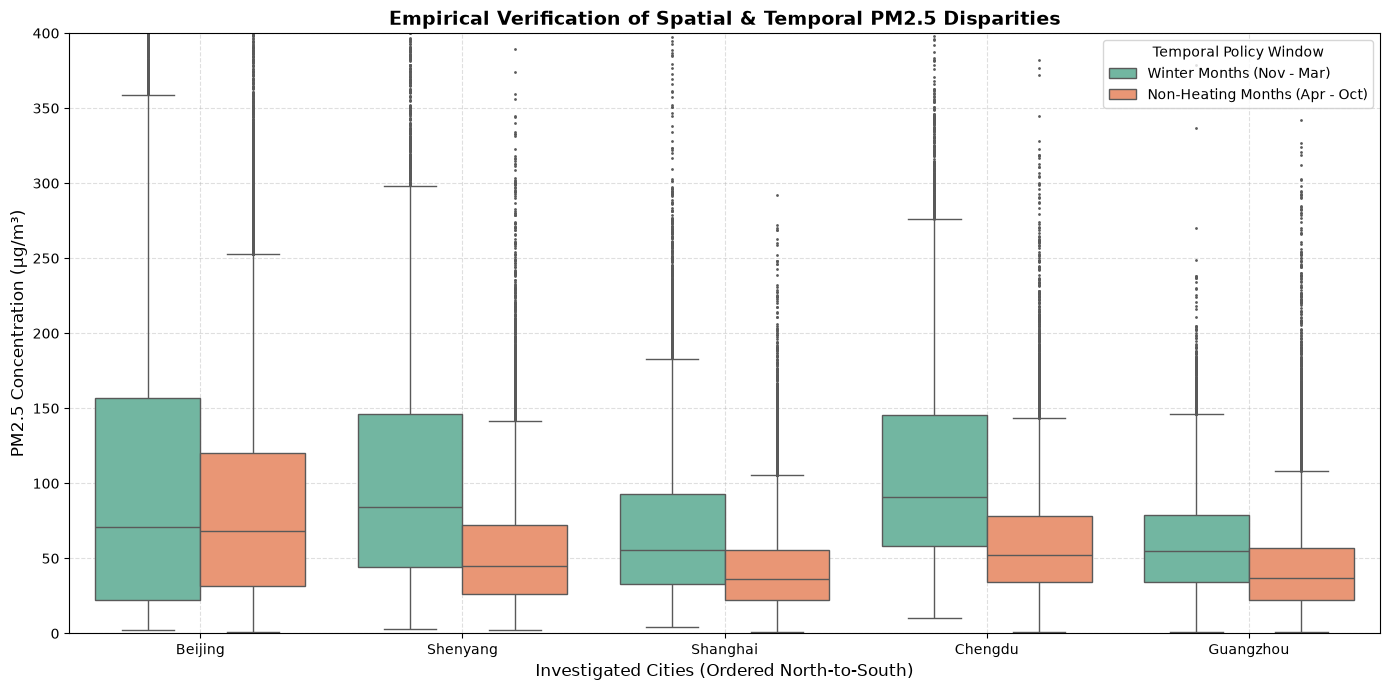

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Define the active heating months based on the northern mandate
HEATING_MONTHS_LIST = [11, 12, 1, 2, 3]

# 2. Create a temporary plotting dataframe to keep the main dataframe untouched
df_plot = df_clean.copy()

# 3. Map the calendar months into two clean temporal scenario groups
df_plot["Timeframe"] = df_plot["month"].apply(
    lambda x: (
        "Winter Months (Nov - Mar)"
        if x in HEATING_MONTHS_LIST
        else "Non-Heating Months (Apr - Oct)"
    )
)

# 4. Enforce the strict geographical panel order from North to South
desired_order = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]

# 5. Build the cross-city policy visualization
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_plot,
    x="city",
    y="PM",
    hue="Timeframe",  # Splits each city panel into concurrent bars
    order=desired_order,
    palette="Set2",
    fliersize=1,  # Downsizes outlier markers for publication layout readability
)

# Economically sensible limitation of the Y-axis to keep the boxes readable
plt.ylim(0, 400)

# Academic formatting adjustments for the final paper layout
plt.title(
    "Empirical Verification of Spatial & Temporal PM2.5 Disparities",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Investigated Cities (Ordered North-to-South)", fontsize=12)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)

# Place the legend cleanly within the plot grid
plt.legend(title="Temporal Policy Window", loc="upper right")
plt.tight_layout()
plt.show()